In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.chdir('/home/jovyan/kuratov/data/test_time_gd/')

import torch

from transformers import GPT2Config, GPT2LMHeadModel

from kv_dataset_utils import create_tokenizer

In [2]:
from grad_memgpt import GradMemGPT

In [3]:
# create tokenizer
tokenizer = create_tokenizer()

In [4]:
from kv_dataset_utils import generate_sequence

num_kv_pairs = 2
k_length = 4
v_length = 4
n_segments = 4
min_segment_len = 32
max_segment_len = 64

sample = generate_sequence(num_kv_pairs, k_length, v_length, n_segments, min_segment_len, max_segment_len)
sample

{'kv_pairs': ['!Qng6:dyBm!', '!fbaA:FRRG!'],
 'segment_ids_to_kv_ids': {0: [1], 1: [0], 2: [], 3: []},
 'context': 'BnHaeSS!fbaA:FRRG!wfQt6IopPp2QToE8nEmtqn77Jk|XBjlTSWckel!Qng6:dyBm!Oaisse0sT1QXxfUrvewDoLvGhh|1QLG4a5YReczPFFGm2OBhA2i3TuEIRw81N064bgN|n6c15nUJVcHQ0VVliOq2S6Hl4CWoTsQ6djF3G3T9lJwmsTmgv3EUIcqXBlxhd|',
 'query': '?!Qng6:',
 'input_sequence': 'BnHaeSS!fbaA:FRRG!wfQt6IopPp2QToE8nEmtqn77Jk|XBjlTSWckel!Qng6:dyBm!Oaisse0sT1QXxfUrvewDoLvGhh|1QLG4a5YReczPFFGm2OBhA2i3TuEIRw81N064bgN|n6c15nUJVcHQ0VVliOq2S6Hl4CWoTsQ6djF3G3T9lJwmsTmgv3EUIcqXBlxhd|?!Qng6:',
 'target': 'dyBm!|'}

In [5]:

from tqdm import tqdm
from datasets import Dataset

num_samples = 5000
data = []
for _ in tqdm(range(num_samples), total=num_samples):
    sample = generate_sequence(num_kv_pairs, k_length, v_length, n_segments, min_segment_len, max_segment_len)
    data += [{
        'context': sample['context'],
        'query': sample['query'],
        'target': sample['target'],
    }]
dataset = Dataset.from_list(data)

100%|██████████| 5000/5000 [00:00<00:00, 17501.57it/s]


In [6]:
from torch.utils.data import DataLoader

def collate_fn(batch, tokenizer):
    context = [item['context'] for item in batch]
    query = [item['query'] + item['target'] for item in batch]
    
    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=False, 
                                  padding=True, pad_to_multiple_of=8).input_ids
    query_input_ids = tokenizer(query, return_tensors="pt", add_special_tokens=False, 
                                padding=True, pad_to_multiple_of=8).input_ids
    # add labels_mask
    # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
    labels_mask = torch.zeros_like(query_input_ids)
    for i, item in enumerate(batch):
        query_seq_len = len(item['query'])
        target_seq_len = len(item['target'])
        labels_mask[i, query_seq_len:query_seq_len+target_seq_len] = 1

    labels = query_input_ids * labels_mask + (1 - labels_mask) * -100
    return {
        'input_ids': {
            'context_input_ids': context_input_ids,
            'query_input_ids': query_input_ids,
        },
        'labels': labels,
    }

def data_collator(batch):
    return collate_fn(batch, tokenizer)

dataloader = DataLoader(dataset, batch_size=2, collate_fn=data_collator)

for batch in dataloader:
    print(batch)
    break

{'input_ids': {'context_input_ids': tensor([[17, 44, 33, 34,  4, 61,  8,  9, 41, 29, 37, 30, 29, 25, 23, 47, 57, 35,
         62, 26, 49, 32, 47, 17,  9,  8, 33, 33,  5, 32, 63, 63, 63, 57, 48,  5,
         11, 58, 31,  7, 54, 48, 57, 62,  5, 31, 43, 59, 69, 31,  7, 21, 16, 26,
         61, 47, 29, 15, 21, 63, 34, 42, 51, 63, 11, 11, 53, 26, 32,  4, 29,  9,
          5, 41, 52, 31, 35,  5, 27, 47, 23, 29, 50, 22, 44, 32, 46, 45, 52, 41,
         55, 14, 24, 52, 50, 21, 61, 23, 51, 22, 46, 31, 69, 19, 44, 60, 26, 50,
         49, 55, 28,  9, 19, 19, 15, 60, 21, 39, 31, 46, 13, 40, 30,  8,  6, 44,
         20, 46, 37, 48, 65, 48, 65, 37,  8, 28, 11,  6, 30, 37, 34, 10, 42, 57,
         43, 16, 22, 59, 27, 37, 65, 35, 58, 41, 48, 69, 24, 59, 66, 14, 46, 56,
         45, 68, 52, 13, 11, 13, 66, 30, 25, 27,  7, 29, 19, 26, 53, 53, 36, 64,
         44, 45, 31,  6, 66, 15, 31, 16, 13, 68, 65, 24, 44, 58, 66, 54, 20, 58,
         39, 30, 36, 69,  0,  0,  0,  0,  0,  0],
        [53, 33, 20, 38

100%|██████████| 100/100 [00:02<00:00, 37.25it/s]


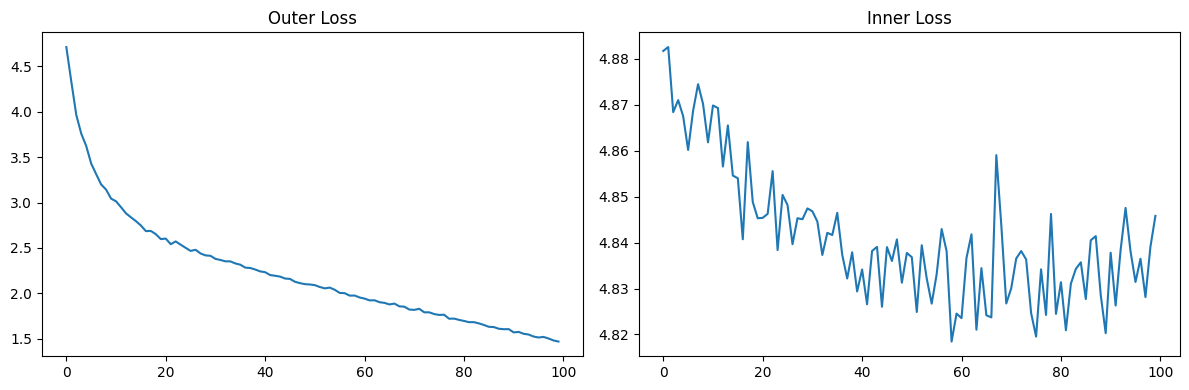

In [7]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=True, grad_mode="none")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    if torch.isnan(loss):
        raise ValueError(f"NaN at step {i}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:01<00:00, 53.52it/s]


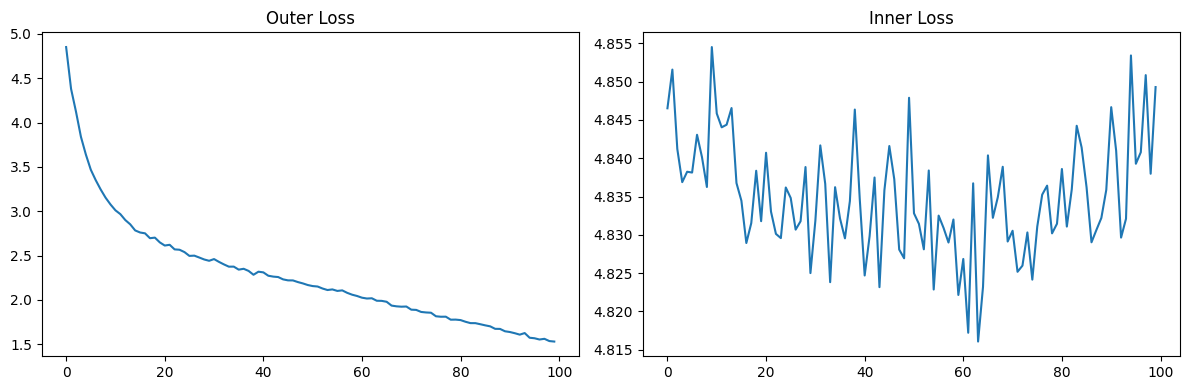

In [8]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=True, grad_mode="first")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:02<00:00, 48.39it/s]


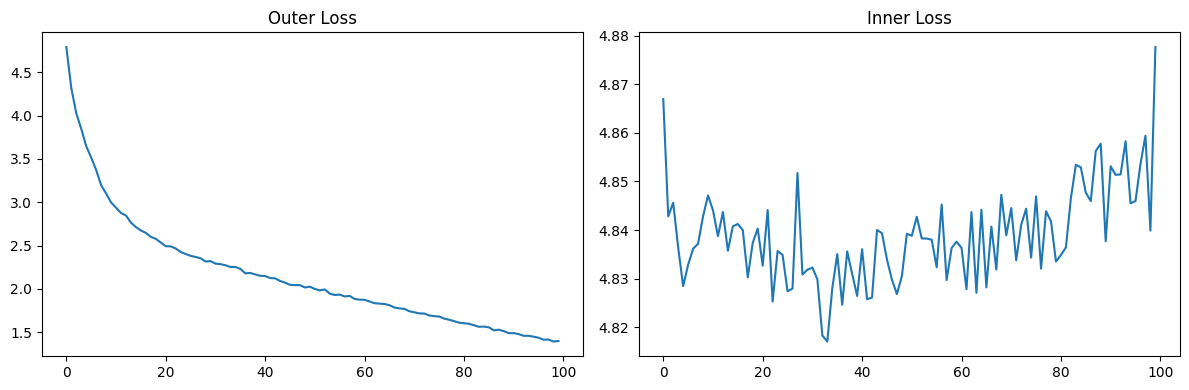

In [9]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=True, grad_mode="second")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:03<00:00, 31.59it/s]


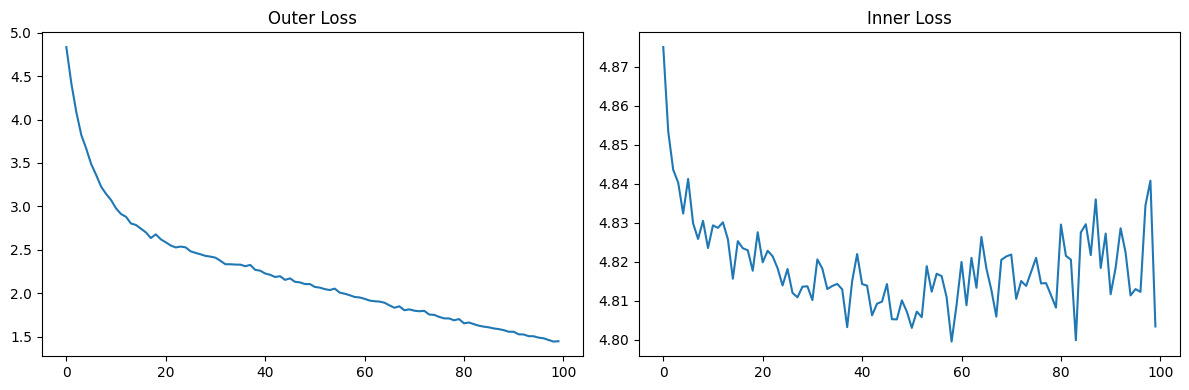

In [10]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 4
config.n_head = 4
config.n_embd = 128
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=0.01, use_adam=False, grad_mode="second")
model = model.to('cuda')

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(100)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [00:06<00:00, 157.39it/s]


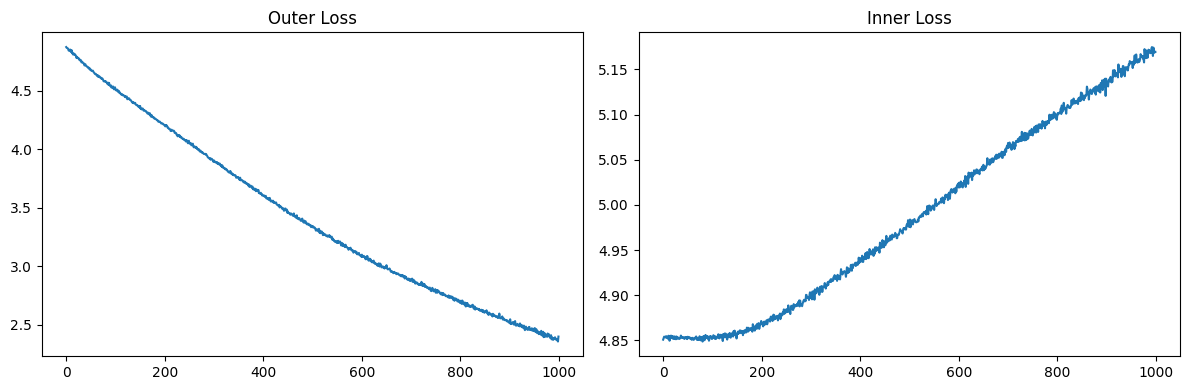

In [64]:
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = 1
config.n_head = 1
config.n_embd = 16
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = GradMemGPT(config=config, n_mem_tokens=8, K=1, lr=1.0, use_adam=True, grad_mode="second", n_ctrl_tokens=1)
model = model.to('cuda')
init_write = model.write_ctrl.clone().detach()
init_read = model.read_ctrl.clone().detach()

from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-04)
out_losses = []
inner_losses = []
for i in tqdm(range(1000)):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    outputs = model(**batch)
    loss = outputs['loss']
    if torch.isnan(loss):
        raise ValueError(f"NaN at step {i}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    out_losses.append(loss.item())
    inner_losses.append(outputs['inner_loss'].item())

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(out_losses)
ax1.set_title('Outer Loss')
ax2.plot(inner_losses)
ax2.set_title('Inner Loss')
plt.tight_layout()
plt.show()

In [65]:
model.write_ctrl == init_write

tensor([[True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True]], device='cuda:0')

In [66]:
model.read_ctrl == init_read

tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False]], device='cuda:0')